# Import Libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

## Load dataset

In [3]:
df = pd.read_csv("clean_data.csv")

df.head()

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
0,1.924176,-0.284236,1.960029,0.959861,-0.446817,-0.364023,0.327518,0.100738,1.074541,-0.410937,2.0,0.0,0.0
1,-0.163476,0.337306,-0.510197,-0.696033,-0.446817,-0.364023,-1.468996,-2.183030,-0.470316,-1.501272,21.0,2.0,0.0
2,-0.645242,0.958849,-0.510197,-0.696033,-0.446817,-0.364023,0.327518,-1.663473,0.642191,-0.410937,13.0,5.0,0.0
3,-0.886125,0.958849,-0.510197,0.959861,-0.446817,-0.364023,0.327518,-0.344596,-0.106511,-0.592660,23.0,2.0,0.0
4,0.719761,1.580391,-0.510197,-0.696033,-0.446817,-0.364023,0.327518,-1.246685,2.039417,-0.229215,11.0,5.0,0.0


## Features and Target

In [4]:
X = df.drop([
    'spam_label',
    'num_special_chars',
    'messages_sent_last_24h',
    'spam_keyword_score',
    'legit_keyword_score'
], axis=1)

y = df['spam_label']

## Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Use Smote

In [7]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(pd.Series(y_train_smote).value_counts())

spam_label
1.0    3382
0.0    3382
Name: count, dtype: int64


## Linear Kernel SVM

In [8]:
svm_linear = SVC(
    kernel='linear',
    random_state=42
)

svm_linear.fit(
    X_train_smote,
    y_train_smote
)

linear_pred = svm_linear.predict(X_test_scaled)

## Evaluation Classification

In [9]:
print("Linear SVM Accuracy:",
      accuracy_score(y_test, linear_pred))

print(classification_report(
    y_test,
    linear_pred
))

Linear SVM Accuracy: 0.9557692307692308
              precision    recall  f1-score   support

         0.0       0.99      0.96      0.97       845
         1.0       0.83      0.95      0.89       195

    accuracy                           0.96      1040
   macro avg       0.91      0.96      0.93      1040
weighted avg       0.96      0.96      0.96      1040



## Confusion Matrix

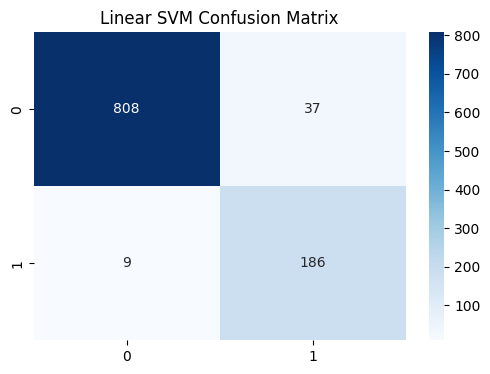

In [10]:
cm = confusion_matrix(y_test,linear_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Linear SVM Confusion Matrix")
plt.show()

## RBF Kernel SVM

In [11]:
svm_rbf = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    random_state=42
)

svm_rbf.fit(
    X_train_smote,
    y_train_smote
)

rbf_pred = svm_rbf.predict(X_test_scaled)

## Evaluation & Classification

In [12]:
print("RBF SVM Accuracy:",
      accuracy_score(y_test, rbf_pred))

print(classification_report(
    y_test,
    rbf_pred
))

RBF SVM Accuracy: 0.9625
              precision    recall  f1-score   support

         0.0       0.99      0.96      0.98       845
         1.0       0.85      0.96      0.91       195

    accuracy                           0.96      1040
   macro avg       0.92      0.96      0.94      1040
weighted avg       0.97      0.96      0.96      1040



## Confusion Matrix

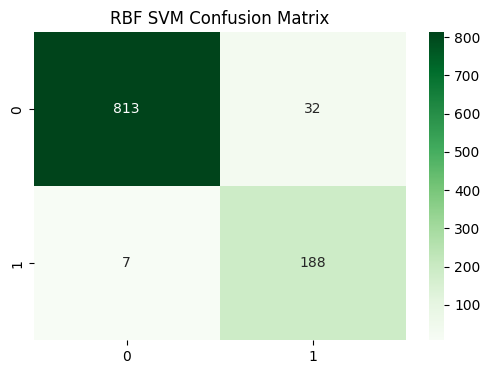

In [13]:
cm = confusion_matrix(
    y_test,
    rbf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("RBF SVM Confusion Matrix")
plt.show()

## Analyze Support Vectors

In [15]:
print("Number of Support Vectors:")

print(svm_rbf.n_support_)

Number of Support Vectors:
[414 421]


## Total Support Vectors

In [16]:
print(
    "Total Support Vectors:",
    svm_rbf.support_vectors_.shape[0]
)

Total Support Vectors: 835


In [17]:
support_percent = (
    svm_rbf.support_vectors_.shape[0]
    /
    len(X_train_smote)
) * 100

print(
    f"Support Vector Percentage: {support_percent:.2f}%"
)

Support Vector Percentage: 12.34%


## Compare SVM with KNN

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_smote,
    y_train_smote
)

knn_pred = knn.predict(
    X_test_scaled
)

## Comparison Table

In [19]:
comparison = pd.DataFrame({

    'Model' : ['KNN','Linear SVM','RBF SVM'],

    'Accuracy' : [
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, linear_pred),
        accuracy_score(y_test, rbf_pred)
    ]
})

print(comparison)

        Model  Accuracy
0         KNN  0.954808
1  Linear SVM  0.955769
2     RBF SVM  0.962500


## Accuracy Comparison Plot

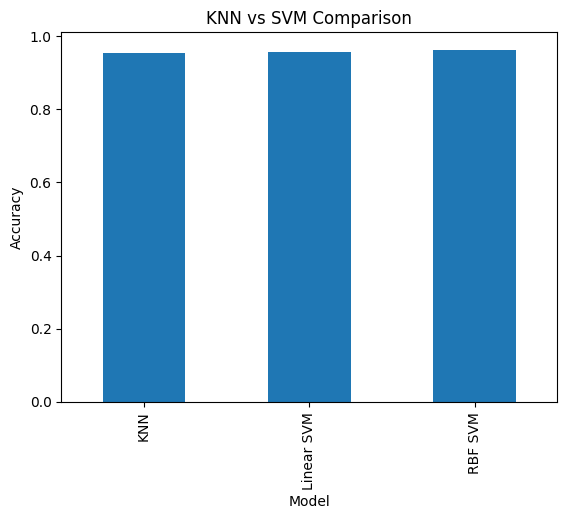

In [20]:
comparison.plot(
    x='Model',
    y='Accuracy',
    kind='bar',
    legend=False
)

plt.title("KNN vs SVM Comparison")
plt.ylabel("Accuracy")
plt.show()

# Conclusion 

Support Vector Machine (SVM) was implemented using Linear and RBF kernels for spam message classification. SMOTE was applied to balance the training data and StandardScaler was used to normalize feature values.

 The RBF kernel achieved better performance than the Linear kernel by capturing non-linear relationships among message features. 
 
 
 Support vectors were analyzed to understand the margin boundaries, and SVM performance was compared with KNN, where SVM generally provided higher accuracy and better spam detection capability.